In [94]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = 'Microsoft YaHei'
%matplotlib inline

#### 一、数据清洗
#### （1）重复值、缺失值、格式调整

In [81]:
data = pd.read_csv('data_wuliu.csv',encoding='gbk')
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1161 entries, 0 to 1160
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   订单号     1159 non-null   object 
 1   订单行     1161 non-null   int64  
 2   销售时间    1161 non-null   object 
 3   交货时间    1161 non-null   object 
 4   货品交货状况  1159 non-null   object 
 5   货品      1161 non-null   object 
 6   货品用户反馈  1161 non-null   object 
 7   销售区域    1161 non-null   object 
 8   数量      1157 non-null   float64
 9   销售金额    1161 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 90.8+ KB


#### 通过info()可以看出，包括10列数据，名字，数据量，格式等可以得出:
#### 1.订单号，货品交货情况和数量都存在缺失值，缺失量不大，可直接删除
#### 2.订单行对分析无关紧要，可以考虑删除
#### 3.销售金额格式不对（万元/元，千分号），数据类型需要转换成int/float

In [82]:
# 删除重复记录
data.drop_duplicates(keep='first',inplace=True)

# 删除缺失值
data.dropna(axis=0,how='any',inplace=True)

# 删除订单行
data.drop(columns=['订单行'],inplace=True,axis=1)
print(data.info())

# 更新索引
data.reset_index(drop=True,inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1146 entries, 0 to 1160
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   订单号     1146 non-null   object 
 1   销售时间    1146 non-null   object 
 2   交货时间    1146 non-null   object 
 3   货品交货状况  1146 non-null   object 
 4   货品      1146 non-null   object 
 5   货品用户反馈  1146 non-null   object 
 6   销售区域    1146 non-null   object 
 7   数量      1146 non-null   float64
 8   销售金额    1146 non-null   object 
dtypes: float64(1), object(8)
memory usage: 89.5+ KB
None


In [83]:
# 清洗销售金额列
# 编写自定义函数：删除逗号，转成float，如果是万元则*10000，否则删除元
def data_deal(number):
    if number.find('万元') != -1: #找到带万元的
        number_new = float(number[:number.find('万元')].replace(',',''))*10000
    else: #找到带有元的
        number_new = float(number.replace('元','').replace(',',''))
    return number_new
data['销售金额'] = data['销售金额'].map(data_deal)
data

,订单号,销售时间,交货时间,货品交货状况,货品,货品用户反馈,销售区域,数量,销售金额
0,P096311,2016-7-30,2016-9-30,晚交货,货品3,质量合格,华北,2.0,105275.0
1,P096826,2016-8-30,2016-10-30,按时交货,货品3,质量合格,华北,10.0,11500000.0
2,P097435,2016-7-30,2016-9-30,按时交货,货品1,返修,华南,2.0,685877.0
3,P097446,2016-11-26,2017-1-26,晚交货,货品3,质量合格,华北,15.0,12958.0
4,P097446,2016-11-26,2017-1-26,晚交货,货品3,拒货,华北,15.0,3239.0
...,...,...,...,...,...,...,...,...,...
1141,P299901,2016-12-15,2017-3-15,按时交货,货品6,质量合格,马来西亚,2.0,20041.0
1142,P302956,2016-12-22,2017-3-22,按时交货,货品2,拒货,华东,20.0,7944.0
1143,P303801,2016-12-15,2017-3-15,按时交货,货品2,质量合格,华东,1.0,19408.0
1144,P307276,2016-12-22,2017-3-22,按时交货,货品6,质量合格,马来西亚,1.0,3218.0


#### （2）异常值处理

In [84]:
data.describe()

,数量,销售金额
count,1146.000000,1.146000e+03
mean,76.069372,1.223488e+05
std,589.416486,1.114599e+06
min,1.000000,0.000000e+00
25%,1.000000,2.941500e+03
50%,1.000000,9.476500e+03
75%,4.000000,3.576775e+04
max,11500.000000,3.270000e+07


In [85]:
# 当销售金额为0，删除
data = data[data['销售金额']!=0]
# 存在严重右偏，符合二八法则，在电商领域很正常，无需处理
data.describe()

,数量,销售金额
count,1145.000000,1.145000e+03
mean,76.134934,1.224557e+05
std,589.669861,1.115081e+06
min,1.000000,5.100000e+01
25%,1.000000,2.946000e+03
50%,1.000000,9.486000e+03
75%,4.000000,3.577300e+04
max,11500.000000,3.270000e+07


#### 二、数据规整

In [132]:
data.loc[:,'销售时间'] = pd.to_datetime(data['销售时间'])
data.loc[:,'月份'] = data['销售时间'].apply(lambda x:x.month)
data

,订单号,销售时间,交货时间,货品交货状况,货品,货品用户反馈,销售区域,数量,销售金额,月份
0,P096311,2016-07-30 00:00:00,2016-9-30,晚交货,货品3,质量合格,华北,2.0,105275.0,7
1,P096826,2016-08-30 00:00:00,2016-10-30,按时交货,货品3,质量合格,华北,10.0,11500000.0,8
2,P097435,2016-07-30 00:00:00,2016-9-30,按时交货,货品1,返修,华南,2.0,685877.0,7
3,P097446,2016-11-26 00:00:00,2017-1-26,晚交货,货品3,质量合格,华北,15.0,12958.0,11
4,P097446,2016-11-26 00:00:00,2017-1-26,晚交货,货品3,拒货,华北,15.0,3239.0,11
...,...,...,...,...,...,...,...,...,...,...
1141,P299901,2016-12-15 00:00:00,2017-3-15,按时交货,货品6,质量合格,马来西亚,2.0,20041.0,12
1142,P302956,2016-12-22 00:00:00,2017-3-22,按时交货,货品2,拒货,华东,20.0,7944.0,12
1143,P303801,2016-12-15 00:00:00,2017-3-15,按时交货,货品2,质量合格,华东,1.0,19408.0,12
1144,P307276,2016-12-22 00:00:00,2017-3-22,按时交货,货品6,质量合格,马来西亚,1.0,3218.0,12


#### 三、数据可视化分析
#### 1.配送服务是否存在问题
#### a.月份维度

In [87]:
data.loc[:,'货品交货状况'] = data['货品交货状况'].str.strip()
data1 = data.groupby(['月份','货品交货状况']).size().unstack()
data1['按时交货率'] = data1['按时交货']/(data1['按时交货']+data1['晚交货'])
data1
# 从按时交货率来看，第四季度低于第三季度，猜测可能是气候原因造成

货品交货状况,按时交货,晚交货,按时交货率
月份,,,
7,189,13,0.935644
8,218,35,0.861660
9,122,9,0.931298
10,238,31,0.884758
11,101,25,0.801587
12,146,18,0.890244


#### b.销售区域维度

In [88]:
data1 = data.groupby(['销售区域','货品交货状况']).size().unstack()
data1['按时交货率'] = data1['按时交货']/(data1['按时交货']+data1['晚交货'])
display(data1.sort_values(by='按时交货率',ascending=False))
# 西北地区存在严重的延时交货问题，可能与地貌有关，急需解决

货品交货状况,按时交货,晚交货,按时交货率
销售区域,,,
泰国,183,4,0.978610
马来西亚,310,16,0.950920
华南,10,1,0.909091
华北,226,27,0.893281
华东,268,39,0.872964
西北,17,44,0.278689


#### c.货品维度

In [89]:
data1 = data.groupby(['货品','货品交货状况']).size().unstack()
data1['按时交货率'] = data1['按时交货']/(data1['按时交货']+data1['晚交货'])
display(data1.sort_values(by='按时交货率',ascending=False))
# 货品4延时交货情况非常严重，其余货品交货情况相对正常

货品交货状况,按时交货,晚交货,按时交货率
货品,,,
货品5,183,4,0.978610
货品6,309,7,0.977848
货品1,27,2,0.931034
货品3,212,26,0.890756
货品2,269,48,0.848580
货品4,14,44,0.241379


#### d.货品和销售区域结合

In [90]:
data1 = data.groupby(['货品','销售区域','货品交货状况']).size().unstack()
data1['按时交货率'] = data1['按时交货']/(data1['按时交货']+data1['晚交货'])
display(data1.sort_values(by='按时交货率',ascending=False))
# 销售区域：西北地区最差，货品有1和4，主要是货品4晚交货导致的
# 货品：货品2最差，送往华东和马来西亚，主要是马来西亚晚交货导致的

货品交货状况     按时交货   晚交货     按时交货率
货品  销售区域                       
货品5 泰国    183.0   4.0  0.978610
货品6 马来西亚  309.0   7.0  0.977848
货品1 华北     14.0   1.0  0.933333
    华南     10.0   1.0  0.909091
货品3 华北    212.0  26.0  0.890756
货品2 华东    268.0  39.0  0.872964
货品4 西北     14.0  44.0  0.241379
货品2 马来西亚    1.0   9.0  0.100000
货品1 西北      3.0   NaN       NaN

#### 2.是否存在尚有潜力的销售区域
#### a.月份维度

<Axes: xlabel='月份'>

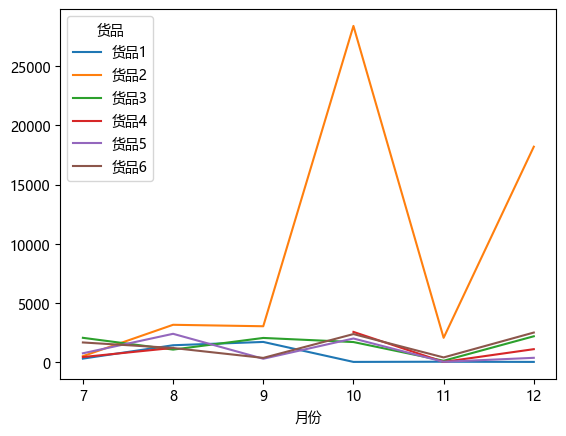

In [96]:
data1 = data.groupby(['月份','货品'])['数量'].sum().unstack()
data1.plot(kind='line')
# 货品2在10月和12月份，销量猛增，原因需结合实际情况分析

#### b.区域维度

In [98]:
data1 = data.groupby(['销售区域','货品'])['数量'].sum().unstack()
data1
# 从销售区域看，每种货品有1~3个销售区域

货品,货品1,货品2,货品3,货品4,货品5,货品6
销售区域,,,,,,
华东,NaN,53811.0,NaN,NaN,NaN,NaN
华北,2827.0,NaN,9073.5,NaN,NaN,NaN
华南,579.0,NaN,NaN,NaN,NaN,NaN
泰国,NaN,NaN,NaN,NaN,5733.0,NaN
西北,11.0,NaN,NaN,5229.0,NaN,NaN
马来西亚,NaN,1510.0,NaN,NaN,NaN,8401.0


#### c.月份和区域维度

In [104]:
data1 = data.groupby(['月份','销售区域','货品'])['数量'].sum().unstack()
data1

货品          货品1      货品2     货品3     货品4     货品5     货品6
月份 销售区域                                                 
7  华东       NaN    489.0     NaN     NaN     NaN     NaN
   华北       1.0      NaN  2041.5     NaN     NaN     NaN
   华南     282.0      NaN     NaN     NaN     NaN     NaN
   泰国       NaN      NaN     NaN     NaN   733.0     NaN
   西北       NaN      NaN     NaN   414.0     NaN     NaN
   马来西亚     NaN      2.0     NaN     NaN     NaN  1649.0
8  华东       NaN   1640.0     NaN     NaN     NaN     NaN
   华北    1410.0      NaN  1045.0     NaN     NaN     NaN
   华南       3.0      NaN     NaN     NaN     NaN     NaN
   泰国       NaN      NaN     NaN     NaN  2381.0     NaN
   西北       NaN      NaN     NaN  1188.0     NaN     NaN
   马来西亚     NaN   1503.0     NaN     NaN     NaN  1181.0
9  华东       NaN   3019.0     NaN     NaN     NaN     NaN
   华北    1409.0      NaN  2031.0     NaN     NaN     NaN
   华南     283.0      NaN     NaN     NaN     NaN     NaN
   泰国       NaN      NaN     NaN     NaN   271.0     NaN
   西北       1.0      NaN     NaN     NaN     NaN     NaN
   马来西亚     NaN      1.0     NaN     NaN     NaN   343.0
10 华东       NaN  28420.0     NaN     NaN     NaN     NaN
   华北       3.0      NaN  1684.0     NaN     NaN     NaN
   泰国       NaN      NaN     NaN     NaN  1984.0     NaN
   西北       1.0      NaN     NaN  2542.0     NaN     NaN
   马来西亚     NaN      NaN     NaN     NaN     NaN  2358.0
11 华东       NaN   2041.0     NaN     NaN     NaN     NaN
   华北       2.0      NaN   100.0     NaN     NaN     NaN
   华南       9.0      NaN     NaN     NaN     NaN     NaN
   泰国       NaN      NaN     NaN     NaN    14.0     NaN
   西北       9.0      NaN     NaN     3.0     NaN     NaN
   马来西亚     NaN      1.0     NaN     NaN     NaN   383.0
12 华东       NaN  18202.0     NaN     NaN     NaN     NaN
   华北       2.0      NaN  2172.0     NaN     NaN     NaN
   华南       2.0      NaN     NaN     NaN     NaN     NaN
   泰国       NaN      NaN     NaN     NaN   350.0     NaN
   西北       NaN      NaN     NaN  1082.0     NaN     NaN
   马来西亚     NaN      3.0     NaN     NaN     NaN  2487.0

In [114]:
display(data1['货品2'].unstack())
# 货品2在10,12月份销量猛增，原因主要发生在原有销售区域（华东）
# 在7,8,9,11月份销售数量还有很大提升空间，可以适当加大营销力度

销售区域,华东,华北,华南,泰国,西北,马来西亚
月份,,,,,,
7,489.0,NaN,NaN,NaN,NaN,2.0
8,1640.0,NaN,NaN,NaN,NaN,1503.0
9,3019.0,NaN,NaN,NaN,NaN,1.0
10,28420.0,NaN,NaN,NaN,NaN,NaN
11,2041.0,NaN,NaN,NaN,NaN,1.0
12,18202.0,NaN,NaN,NaN,NaN,3.0


#### 3.商品是否存在质量问题

In [130]:
data.loc[:,'货品用户反馈'] = data['货品用户反馈'].str.strip()
data1 = data.groupby(['货品','销售区域'])['货品用户反馈'].value_counts().unstack()
data1['拒货率'] = data1['拒货']/data1.sum(axis=1)
data1['返修率'] = data1['返修']/data1.sum(axis=1)
data1['合格率'] = data1['质量合格']/data1.sum(axis=1)
data1.sort_values(['合格率','返修率','拒货率'],ascending=False)
# 货品3,6,5合格率均较高，返修率较低，说明质量还可以
# 货品1,2,4合格率均较低，返修率也高，说明质量还存在一定问题，需要改善
# 货品2在马来西亚拒货率很高，结合按时交货率也很低，需重视

货品用户反馈      拒货   质量合格    返修       拒货率       返修率       合格率
货品  销售区域                                                 
货品3 华北    31.0  188.0  19.0  0.130252  0.079788  0.789219
货品6 马来西亚  56.0  246.0  14.0  0.177215  0.044279  0.777936
货品5 泰国    14.0  144.0  29.0  0.074866  0.155018  0.769108
货品2 华东    72.0  184.0  51.0  0.234528  0.165997  0.598568
货品1 华南     5.0    4.0   2.0  0.454545  0.174603  0.343963
    西北     NaN    1.0   2.0       NaN  0.666667  0.272727
    华北     NaN    3.0  12.0       NaN  0.800000  0.189873
货品4 西北     NaN    9.0  49.0       NaN  0.844828  0.152945
货品2 马来西亚   6.0    1.0   3.0  0.600000  0.283019  0.091886